Fitting SVI Model to Call Options (CE)...
Fitting SVI Model to Put Options (PE)...
 saved 'filled_dataset.csv' using SVI


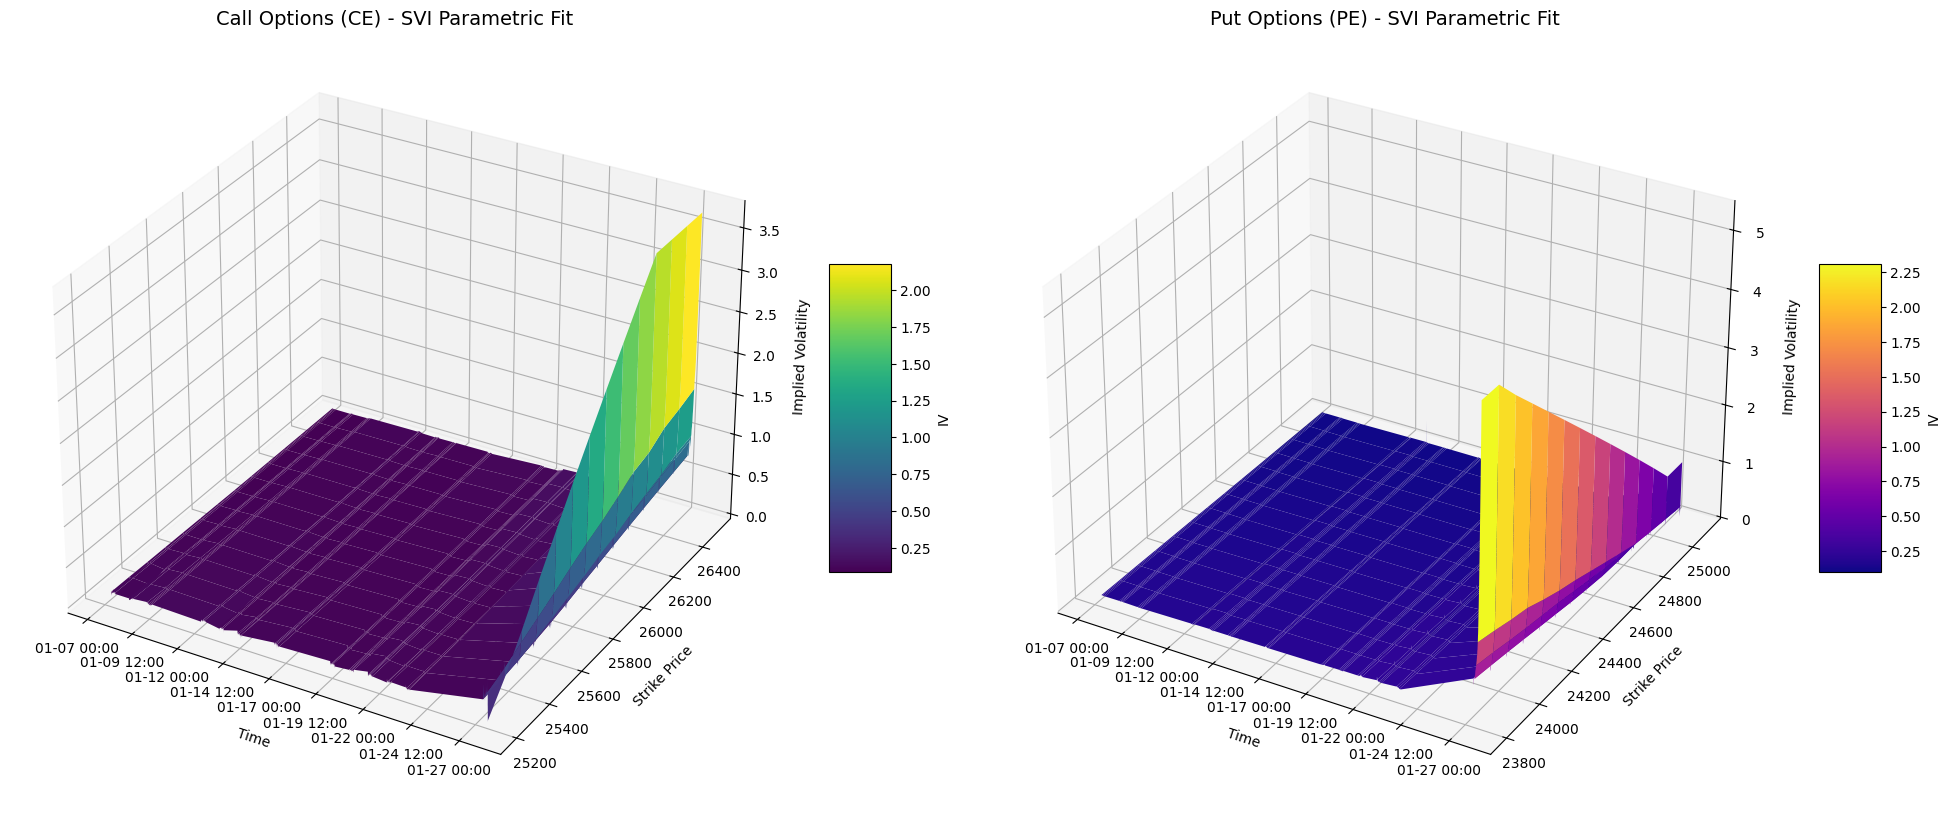

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

# ==========================
# 1. The SVI Equation


def svi_variance(k, a, b, rho, m, s):
    """
    k: log-moneyness ln(Strike/Underlying)
    Returns: Variance (IV squared)
    """
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + s**2))


    
def process_with_svi(file_path):
    # 2. import data
    df = pd.read_csv(file_path)
    df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')

# ==================================
    # Function to apply  SVI Imputation for each row
    
  
    def fit_svi(df_full, option_type):
        cols = [col for col in df_full.columns if col.endswith(option_type)]
        strikes = np.array([int(c.replace('NIFTY27JAN26', '').replace(option_type, '')) for c in cols])
        
        
        # Sort by strike
        sorted_indices = np.argsort(strikes)
        strikes = strikes[sorted_indices]
        sorted_cols = np.array(cols)[sorted_indices]
        
        df_opt = df_full[sorted_cols].copy()
        df_filled = df_opt.copy()
        
        
        # Fit SVI row by row
        for idx, row in df_full.iterrows():
            S = row['underlying_price']
            iv_row = df_opt.loc[idx].values
            k = np.log(strikes / S)
            
            # Find points that we already have tht data of
            valid_mask = ~np.isnan(iv_row)
            
            # We need at least 6 points
            if valid_mask.sum() > 5:
                k_valid = k[valid_mask]
                var_valid = iv_row[valid_mask] ** 2  # Convert IV to Variance
                
                # Initial Guess of paraeters: [a, b, rho, m, s]
                p0 = [np.min(var_valid), 0.1, 0.0, 0.0, 0.1]
                
                # Mathematical boundaries for SVI parameters
                bounds = (
                    [-np.inf, 0.0001, -0.999, -np.inf, 0.001], # Lower bounds
                    [np.inf,  np.inf,  0.999,  np.inf, np.inf]   # Upper bounds
                )
                
                try:
                    # Run the curve_fit function
                    popt, _ = curve_fit(svi_variance, k_valid, var_valid, p0=p0, bounds=bounds, maxfev=10000)
                    
                    # Generate the perfectly smooth curve for ALL strikes
                    var_pred = svi_variance(k, *popt)
                    var_pred = np.maximum(var_pred, 1e-6) # Prevent variance < 0
                    iv_pred = np.sqrt(var_pred)
                    
                    # omlu fill the missing values
                    missing_mask = np.isnan(iv_row)
                    df_filled.loc[idx, sorted_cols[missing_mask]] = iv_pred[missing_mask]
                except RuntimeError:
                    # Fallback to cubic if the optimizer fails to output for this row
                    df_filled.loc[idx] = df_opt.loc[idx].copy()
            
        # Final pass: Any remaining NaNs (from fallback rows) get standard cubic interpolation
        df_filled.columns = strikes
        df_filled = df_filled.interpolate(method='cubic', axis=1).ffill(axis=1).bfill(axis=1)
        df_filled.columns = sorted_cols
        
        return df_filled, strikes, sorted_cols

# =====================================================
    # 3. run for both CE and PE

    print("Fitting SVI Model to Call Options (CE)...")
    df_ce_filled, ce_strikes, ce_cols = fit_svi(df, 'CE')
    
    print("Fitting SVI Model to Put Options (PE)...")
    df_pe_filled, pe_strikes, pe_cols = fit_svi(df, 'PE')

    # Combine back into single dataset
    df_filled = df.copy()
    for col in ce_cols: df_filled[col] = df_ce_filled[col]
    for col in pe_cols: df_filled[col] = df_pe_filled[col]

    df_filled.to_csv('filled_dataset.csv', index=False)
    print(" saved 'filled_dataset.csv' using SVI")

# ====================================
    # 4. Plotting

    fig = plt.figure(figsize=(20, 8))
    X_num = mdates.date2num(df['datetime'].values)
    X_ce_num, Y_ce = np.meshgrid(X_num, ce_strikes)
    X_pe_num, Y_pe = np.meshgrid(X_num, pe_strikes)

    # --- Plot CE Surface ---
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X_ce_num, Y_ce, df_ce_filled.values.T, cmap='viridis', edgecolor='none')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax1.set_title('Call Options (CE) - SVI Parametric Fit', fontsize=14)
    ax1.set_xlabel('\nTime')
    ax1.set_ylabel('\nStrike Price')
    ax1.set_zlabel('\nImplied Volatility')
    fig.colorbar(surf1, ax=ax1, shrink=0.4, aspect=5, label='IV')

    # --- Plot PE Surface ---
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X_pe_num, Y_pe, df_pe_filled.values.T, cmap='plasma', edgecolor='none')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax2.set_title('Put Options (PE) - SVI Parametric Fit', fontsize=14)
    ax2.set_xlabel('\nTime')
    ax2.set_ylabel('\nStrike Price')
    ax2.set_zlabel('\nImplied Volatility')
    fig.colorbar(surf2, ax=ax2, shrink=0.4, aspect=5, label='IV')

    plt.tight_layout()
    plt.show()

# Run finally
if __name__ == "__main__":
    process_with_svi('dataset.csv')